Linear Regression from Scratch

Import libraries

In [9]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
# Load data 
data = pd.read_csv('Salary_Data.csv')
data.head()

,YearsExperience,Salary
0,1.1,39343
1,1.3,46205
2,1.5,37731
3,2.0,43525
4,2.2,39891


In [ ]:
#assign columns as feature and target 
X = data['YearsExperience']
y = data['Salary']


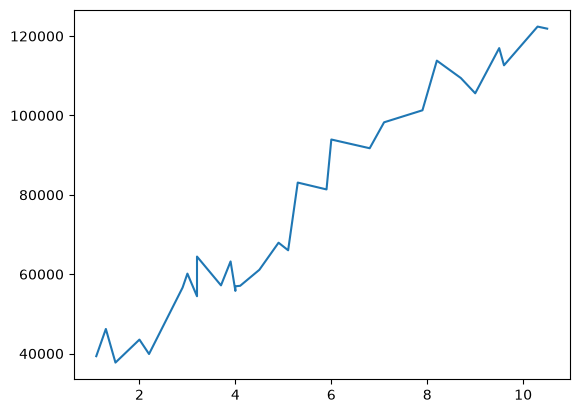

In [12]:
plt.plot(X,y)

In [ ]:
#Converting into Numpy array for easier calculation
X = np.array(X)
y = np.array(y)

In [18]:
#Normalizing the value of X (Z normalization)
def mean(X):
    return np.sum(X)/len(X)

def variance(X):
    mean_val = mean(X)
    return np.sum(((X-mean_val)**2)/len(X))

def z_norm(X):
    mean_val = mean(X)
    var = variance(X)
    return (X-mean_val)/np.sqrt(var)

In [19]:
X_final = z_norm(X)

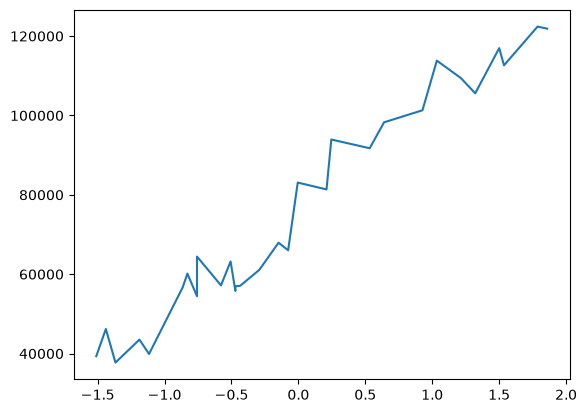

In [20]:
plt.plot(X_final,y)

In [ ]:
#Linear regression model from scratch
class LinearRegression:
    def __init__(self, learn_rate=0.1 ,max_iter=2000 ,threshold_val=1e-6):
        self.learn_rate = learn_rate
        self.max_iter = max_iter
        self.threshold_val = threshold_val
        self.weight = 0
        self.bias = 0

    def predict(self , X):
        return self.weight * X + self.bias

    def fit(self, X , y):
        n = len(X)
        loss_history = []
        errors = y - self.predict(X) # --> First run
        prev_loss = (1/(2*n))*np.sum(errors**2)
        loss_history.append(prev_loss)
        for i in range(self.max_iter):
            w_grad = (1/n)*np.sum(errors*X) # --> Gradient values that updates
            b_grad = (1/n)*np.sum(errors)
            self.weight += self.learn_rate * w_grad
            self.bias += self.learn_rate * b_grad
            y_pred = self.predict(X)
            errors = y - y_pred
            curr_loss = (1/(2*n))*np.sum(errors**2)
            if np.abs(curr_loss - prev_loss)<self.threshold_val: #--> 
                break
            prev_loss = curr_loss
            loss_history.append(curr_loss)
        return loss_history

    def plot(self , X, y):
        y_pred = self.predict(X)
        plt.plot(X,y)
        plt.plot(X,y_pred)
    

In [22]:
model = LinearRegression()

In [23]:
loss_history = model.fit(X_final,y)

In [24]:
loss_history

[np.float64(3251477635.366667),
 np.float64(2636667625.0606165),
 np.float64(2138671516.712716),
 np.float64(1735294668.9509168),
 np.float64(1408559422.263859),
 np.float64(1143903872.4473429),
 np.float64(929532877.0959644),
 np.float64(755892370.8613477),
 np.float64(615243560.8113084),
 np.float64(501318024.67077637),
 np.float64(409038340.3969457),
 np.float64(334291796.1351426),
 np.float64(273747095.2830821),
 np.float64(224705887.59291327),
 np.float64(184982509.36387646),
 np.float64(152806572.99835667),
 np.float64(126744064.5422856),
 np.float64(105633432.69286802),
 np.float64(88533820.89483976),
 np.float64(74683135.33843686),
 np.float64(63464080.03775053),
 np.float64(54376645.24419456),
 np.float64(47015823.06141433),
 np.float64(41053557.093362324),
 np.float64(36224121.65924017),
 np.float64(32312278.95760121),
 np.float64(29143686.369273636),
 np.float64(26577126.372728378),
 np.float64(24498212.775526684),
 np.float64(22814292.76179328),
 np.float64(21450317.5506692

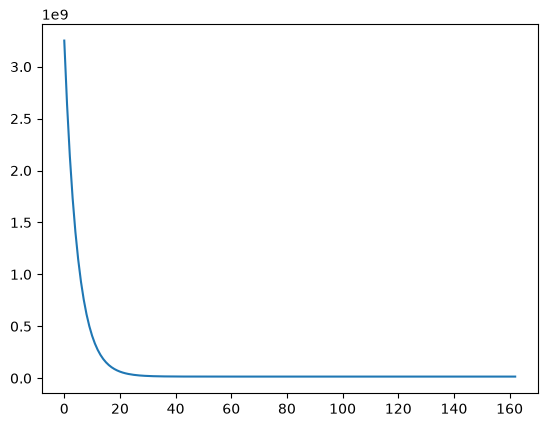

In [25]:
plt.plot(loss_history)

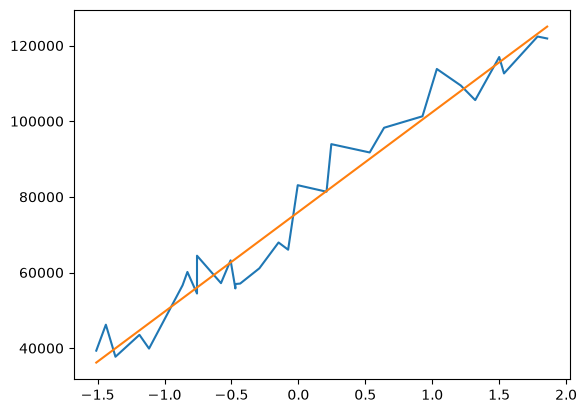

In [26]:
model.plot(X_final,y)